# Exploration de la qualité des données

Le but de ce notebook est de vérifier si les données collectées sont suffisamment fiables et pertinentes pour notre sujet.

En l'occurence, nous vérifierons dans un premier temps les valeurs manquantes, les doublons,... c'est-à-dire si les données sont colectées de manière correctes.

Ensuite, il s'agira de vérifier si ces données sont récentes, si elles concernent les joueurs et clubs qui nous intéressent et si les variables proposées sont suffisantes pour notre analyse.

Nous importons tout d'abord les packages nécessaires à notre première analyse exploratoire.

In [2]:
import sys
import os

# On connecte le notebook à tous les fichiers inclus dans le dossier /fonctions
sys.path.append(os.path.abspath("../fonctions"))

# On importe toutes les fonctions dans le fichier imports.py
from utils import * # type: ignore

# I. Analyse de la qualité des données (Transfermarkt)

Avant d'intégrer les statistiques de performance, il est impératif de valider la fiabilité de notre variable cible : la **Valeur Marchande**. 
Cette phase permet de comprendre la structure du marché, d'identifier les segments de joueurs et de nettoyer les données pour garantir la précision du futur modèle prédictif.

### 0. Source des Données et Traçabilité
Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via l'API Kaggle. 

* **Dataset :** [Football Data from Transfermarkt](https://www.kaggle.com/datasets/davidcariboo/player-scores)
* **Identifiant :** `davidcariboo/player-scores`
* **Dernière mise à jour du dataset :** 2026-04-01

In [3]:
# Tu passes l'identifiant Kaggle ici
identifiant = 'davidcariboo/player-scores'
date_update = get_kaggle_dataset_last_update(identifiant)

Dataset trouvé : davidcariboo/player-scores
Dernière mise à jour : 2026-04-01 09:41:00.553000


### 1. Analyse Exploratoire de la Population
L'examen initial des distributions révèle trois piliers fondamentaux de la valorisation des joueurs :

* **Distribution des Prix :** On observe une "longue traîne" extrême. La majorité des joueurs se situe sous les 5M€, tandis qu'une élite très restreinte dépasse les 100M€. Cette asymétrie impose une approche logarithmique pour la modélisation.
* **Courbe des Âges :** La distribution suit une courbe de Gauss centrée sur **25-28 ans**. La valeur marchande étant intrinsèquement liée au potentiel de revente et au "prime" physique, l'âge sera une variable explicative non-linéaire majeure.
* **Segmentation par Ligue (Big 5) :** Les boxplots confirment un marché à plusieurs vitesses. La **Premier League** affiche non seulement la médiane la plus haute mais aussi la plus forte concentration de superstars (outliers). À talent égal, le facteur "Ligue" influence drastiquement le prix final.

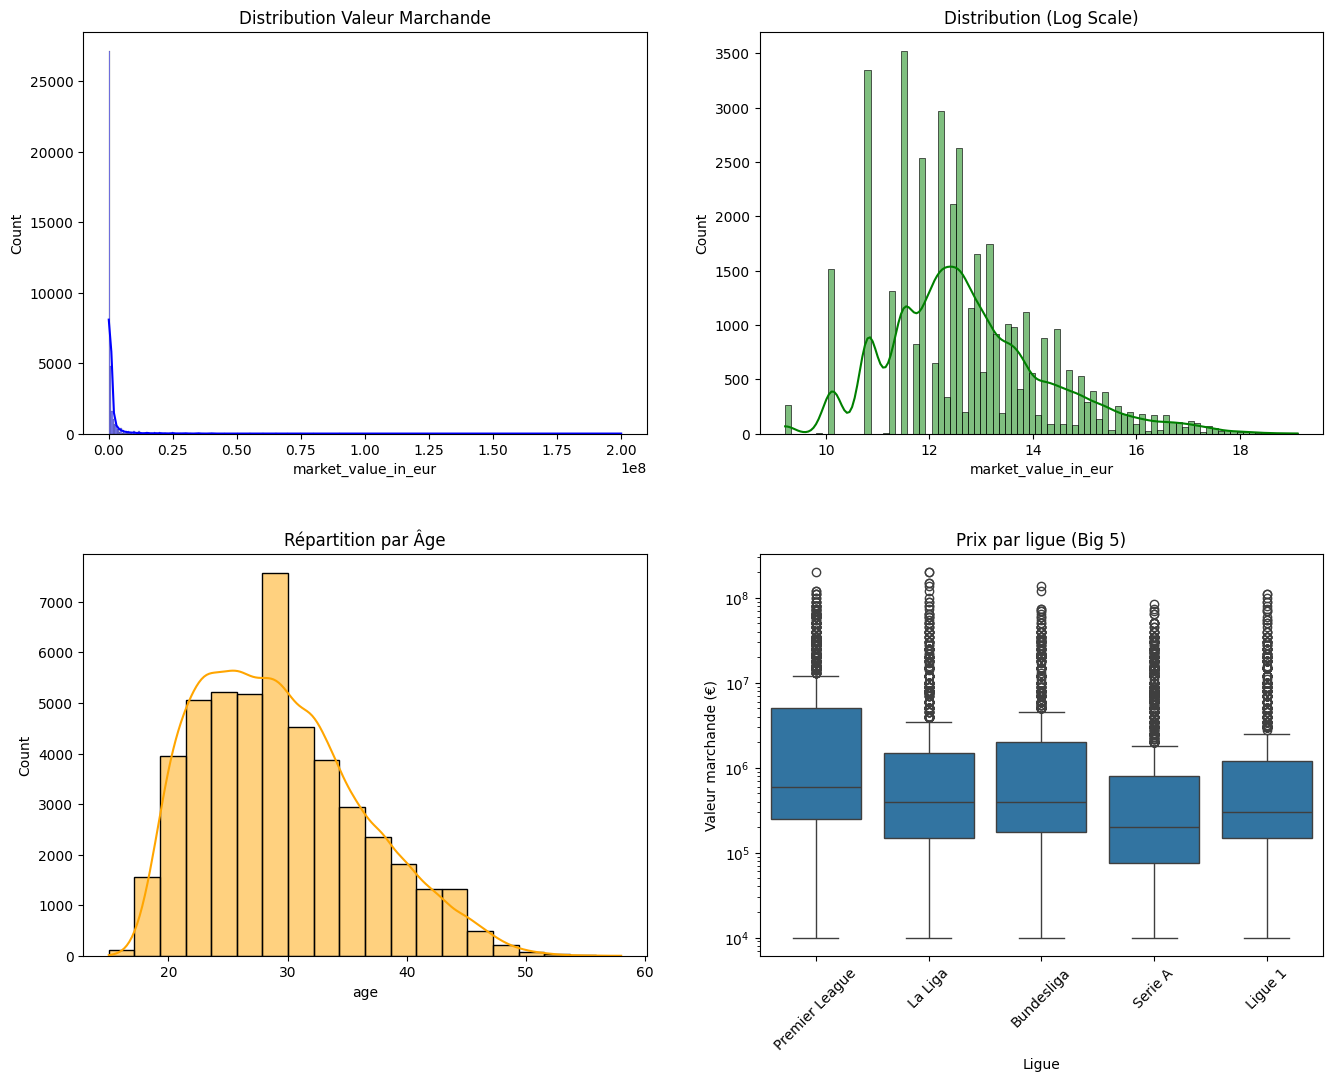

In [4]:
# Chargement des fichiers
df_players = pd.read_csv("../data/transfermarkt_datasets/players.csv")
df_clubs = pd.read_csv("../data/transfermarkt_datasets/clubs.csv")

# Appel de la fonction avec les deux dataframes
plot_transfermarkt_quality(df_players, df_clubs)

### 2. Fraîcheur et Pertinence Temporelle
Le graphique des dates de dernières évaluations est un indicateur de fiabilité :

* **Obsolescence :** Une partie du dataset contient des prix n'ayant pas été mis à jour depuis plusieurs années (2012-2022). Ces données sont "mortes" statistiquement car elles ne correspondent plus aux performances actuelles.
* **Décision :** Pour corréler efficacement les prix aux statistiques de performance récentes, nous filtrerons les joueurs dont la dernière évaluation est antérieure à **octobre 2025**.

Nombre total d'évaluations dans l'historique : 616377
Nombre de joueurs uniques évalués : 39361
------------------------------
Date de l'évaluation la plus ancienne (historique) : 2000-01-20
Date de l'évaluation la plus récente (marché actuel) : 2026-03-30


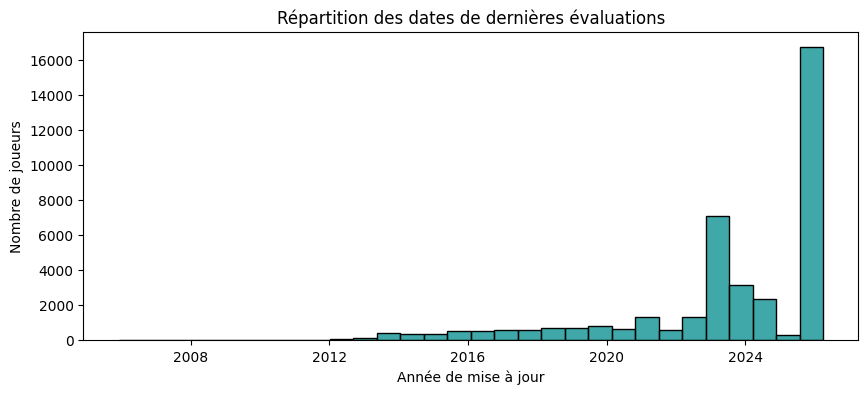

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
4565,16733,2005-12-02,100000,Malmö FF,678.0,DK1
15907,73096,2008-04-16,50000,CA Metropolitano,982.0,PO1
31935,62553,2009-10-25,200000,Hibernian FC,2759.0,SC1
34306,134354,2009-12-28,50000,Unknown,498.0,BE1
37808,144619,2010-03-15,25000,Spartak Moskow II,232.0,RU1
...,...,...,...,...,...,...
616287,673173,2026-03-30,1400000,IF Elfsborg,1101.0,SE1
616288,685657,2026-03-30,2000000,BK Häcken,1109.0,SE1
616289,688019,2026-03-30,800000,IF Brommapojkarna,1092.0,SE1
616283,666951,2026-03-30,900000,IFK Göteborg,801.0,SE1


In [5]:
# Chargement de l'historique des valeurs marchandes
df_valuations = pd.read_csv("../data/transfermarkt_datasets/player_valuations.csv")

# Convertir la colonne date en format datetime
get_latest_player_valuations(df_valuations, plot_freshness=True)

Nombre total d'évaluations dans l'historique : 616377
Nombre de joueurs uniques évalués : 39361
------------------------------
Date de l'évaluation la plus ancienne (historique) : 2000-01-20
Date de l'évaluation la plus récente (marché actuel) : 2026-03-30


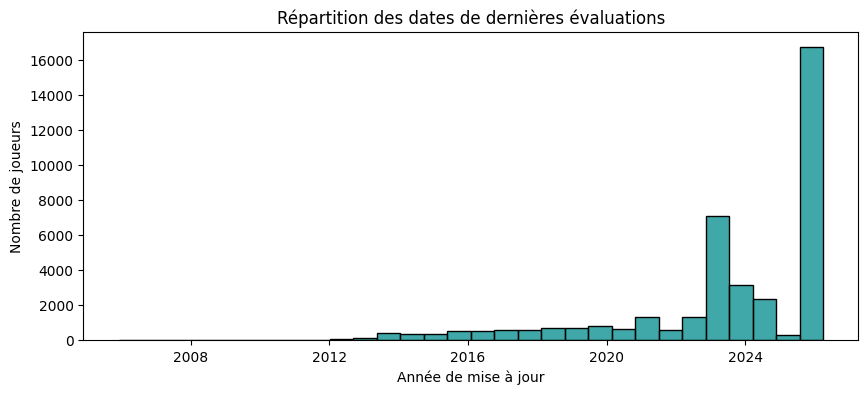

🧹 Filtre de fraîcheur appliqué (Seuil : 2025-10-01) :
- Joueurs conservés : 16743
- Joueurs écartés (données trop anciennes) : 22618
- Plage finale : du 2025-10-01 au 2026-03-30
Date la plus ancienne conservée : 2005-12-02
Date la plus récente : 2026-03-30


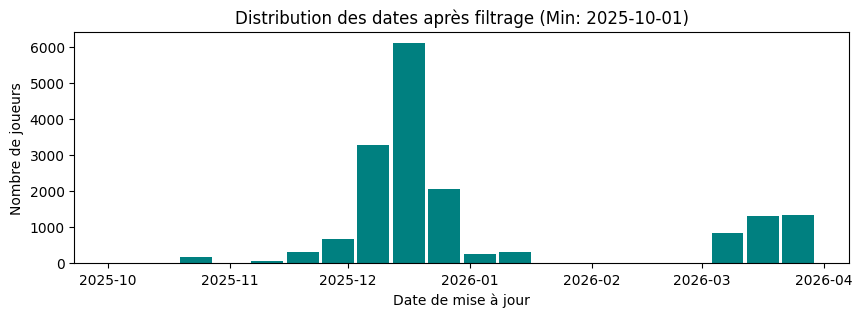

In [6]:
df_latest_values = get_latest_player_valuations(df_valuations, plot_freshness=True)

# Utilisation de la fonction avec ton seuil personnalisé
df_market_final = filter_valuation_freshness(df_latest_values, threshold_date='2025-10-01')

### 3. Détection Statistique des Outliers (Z-Score > 3)
En utilisant la méthode du Z-score sur la valeur marchande, nous isolons mathématiquement les joueurs "hors-normes" :

* **Seuil de Rupture :** Le calcul fixe la limite de la normalité à **41.2 M€**. Au-delà, le joueur est considéré comme un outlier statistique (Top 1.7% des joueurs).
* **Visualisation Jitter :** Le graphique en échelle logarithmique montre que les outliers (en rouge) s'étendent jusqu'à 200M€. 
* **Conclusion :** Ces points ne sont pas des erreurs mais des "phénomènes". Ils nécessitent un traitement particulier pour ne pas biaiser la moyenne, tout en étant conservés pour leur haute valeur informative.

In [ ]:
# On utilise df_latest_values (le DataFrame avec une seule ligne par joueur)
df_latest_values = df_latest_values[df_latest_values['market_value_in_eur'] >= 1_000_000]
outliers_prix = detect_outliers_zscore(df_latest_values, 'market_value_in_eur')

Analyse de market_value_in_eur :
- Moyenne : 6319662.85 | Écart-type : 11643155.79
- Nombre d'outliers détectés (> 3 std) : 149


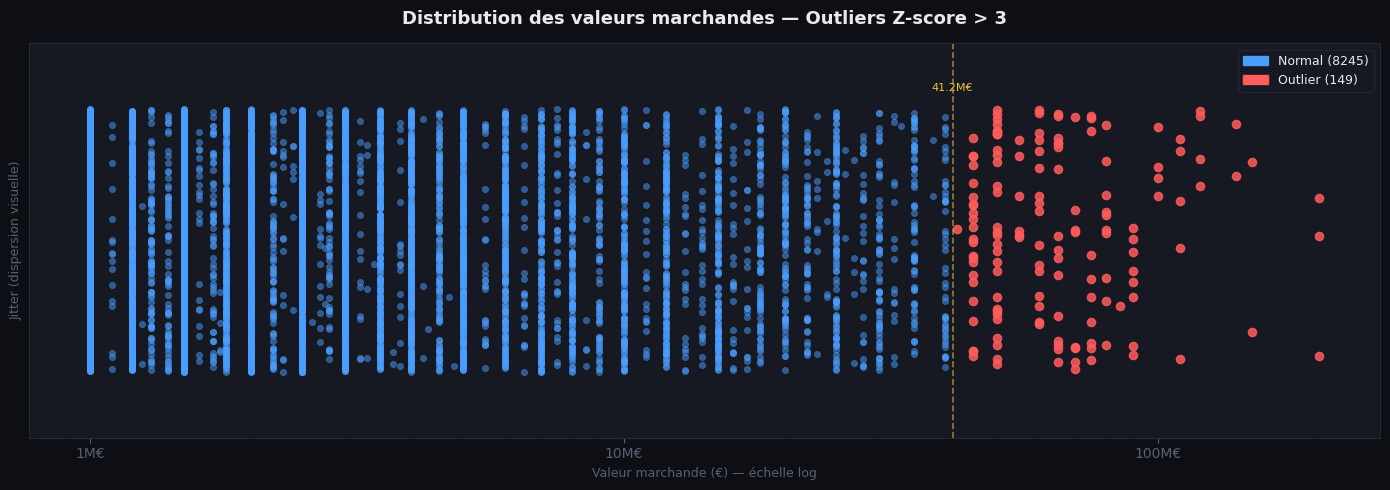

In [8]:
# ── Appel ──────────────────────────────────────────────────────────────────────
plot_outliers_jitter(df_latest_values, 'market_value_in_eur', outliers_prix)

### 4. Diagnostic de l'Intégrité des Données
Le nettoyage technique repose sur trois vérifications critiques :

* **Valeurs Manquantes (NaN) :** 18% des joueurs n'ont pas de valeur cible (prix) et sont donc exclus. Les statistiques internationales manquantes sont imputées à `0` (joueurs non-sélectionnés).
* **Doublons :** Seuls 2 doublons (Nom/Date de naissance) ont été détectés, prouvant la robustesse des identifiants `player_id`.
* **Intégrité Référentielle (Orphelins) :** 135 joueurs possèdent un historique de prix mais aucune fiche de profil associée. Ces orphelins sont supprimés car nous n'avons aucune caractéristique (âge, position, club) pour expliquer leur prix.

c:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\fonctions\utils.py:167: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.index, y=missing_pct.values, palette="Reds_r")


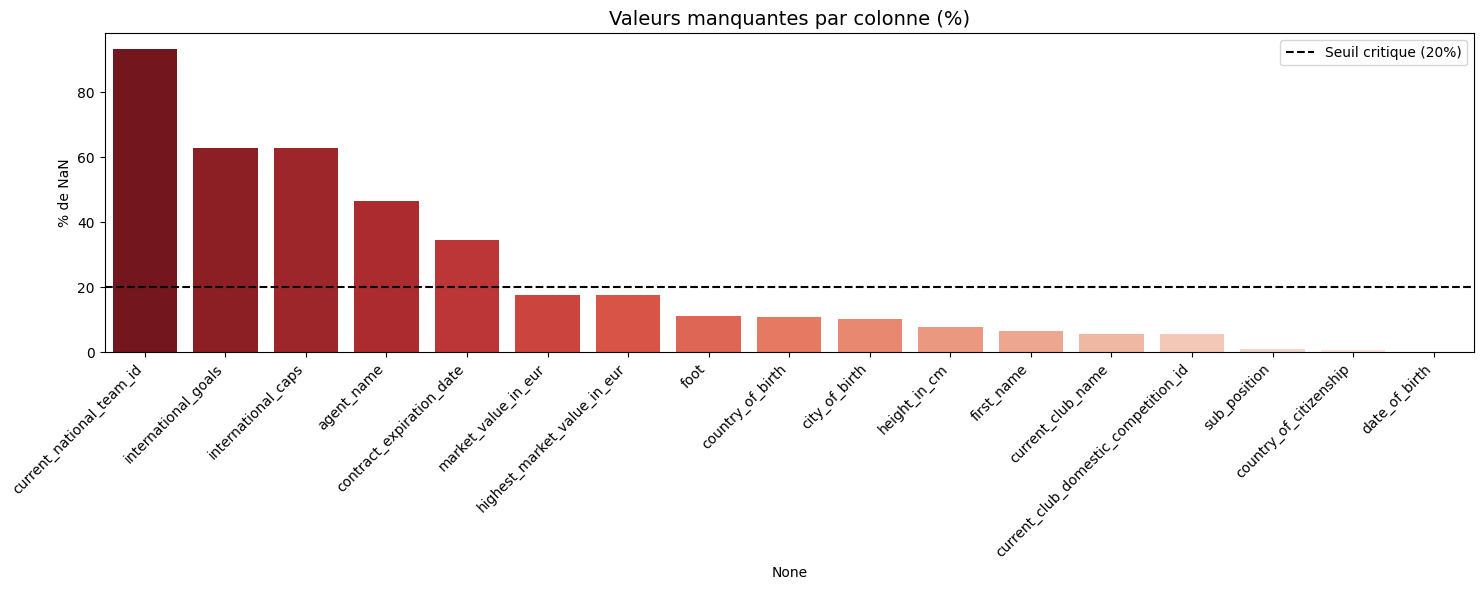

In [9]:
# 2. Analyse des valeurs manquantes (Contrats et Cible)
check_all_missing_values(df_players)

In [10]:
check_player_duplicates(df_players)

⚠️ 2 doublons potentiels détectés (même nom et date de naissance).


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
23679,398057,João,Ricciulli,João Ricciulli,2018,1038,joao-ricciulli,Guinea-Bissau,Bissau,Guinea-Bissau,...,Evlon Sports & Mgmt,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/joao-ricciulli...,IT1,UC Sampdoria,25000.0,100000.0
26162,461923,João,Ricciulli,João Ricciulli,2022,2420,joao-ricciulli,NaN,Bissau,NaN,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/joao-ricciulli...,PO1,Vitória Sport Clube,100000.0,100000.0


In [11]:
# On vérifie l'intégrité avant d'aller plus loin
orphans_list = check_referential_integrity(df_players, df_market_final)

🔍 Analyse de l'intégrité référentielle :
- Joueurs dans le fichier Profil : 47702
- Joueurs dans le fichier Valuations : 16743
----------------------------------------
⚠️  ALERTE : 130 joueurs ont des prix mais n'ont pas de profil.
👉 Ces prix seront perdus lors de la jointure (Merge).
Exemples d'IDs orphelins : [910848, 552960, 131074, 910851, 751104]


### 5. Synthèse du Nettoyage Final
Pour obtenir un dataset prêt pour l'entraînement, les filtres suivants sont appliqués :

1.  **Filtre de Valeur :** Seuil minimal de **1 000 000 €** (élimination du bruit des ligues mineures).
2.  **Filtre de Fraîcheur :** Évaluations postérieures à 2025 uniquement.
3.  **Suppression des colonnes vides :** Retrait de `agent_name` et `current_national_team_id`.
4.  **Unicité :** Conservation de la valeur la plus récente par joueur.

In [12]:
# Appel de la fonction
df_market_final = process_market_data(
    df_players, 
    df_valuations, 
    threshold_date='2025-10-01', 
    min_value=1_000_000
)

✅ PIPELINE DE VALORISATION TERMINÉ
- Joueurs conservés : 6794
- Valeur min : 1,000,000 €
- Plage temporelle : du 2025-10-01 au 2026-03-30


# II. Analyse de la qualité des données (FBref)

### 0. Source des Données et Traçabilité
Afin de garantir la reproductibilité de cette analyse, les données sont extraites directement via l'API Kaggle. 

* **Dataset :** [Football Players Stats (2025-2026)](https://www.kaggle.com/datasets/hubertsidorowicz/football-players-stats-2025-2026)
* **Identifiant :** `hubertsidorowicz/football-players-stats-2025-2026`
* **Dernière mise à jour du dataset :** 2026-04-21

In [3]:
# L'identifiant du Kaggle
identifiant = 'hubertsidorowicz/football-players-stats-2025-2026'

# La date de dernière mise à jour
date_update = get_kaggle_dataset_last_update(identifiant)

Dataset trouvé : hubertsidorowicz/football-players-stats-2025-2026
Dernière mise à jour : 2026-04-21 12:40:14.337000


### 1. Filtrage de Représentativité (Data Cleaning)
Le dataset FBref brut contient l'intégralité des joueurs ayant foulé la pelouse, même pour quelques secondes. Pour garantir la robustesse statistique de notre modèle, un filtrage sur le temps de jeu est impératif.

* **Seuil de fiabilité :** Nous avons fixé un minimum de **450 minutes jouées** (l'équivalent de 5 matchs complets). 
* **Impact sur le volume :** Ce filtre réduit le dataset de **30.7%**, passant de 2 751 à 1 907 joueurs. Bien que la perte de données semble importante, elle est nécessaire pour éliminer le "bruit" statistique.
* **Correction des biais (Exemple concret) :** * Avant filtrage, des joueurs comme *Marin Ljubicic* affichaient un ratio de **8.18 buts / 90 min** (car il a marqué 2 buts en seulement 22 minutes). 
    * En conservant ces profils, le modèle d'IA apprendrait des corrélations erronées, pensant que l'efficacité est décorrélée du temps de jeu réel.
* **Segmentation des postes :** Nous avons isolé **1 777 joueurs de champ** et **130 gardiens de but**. Cette séparation est fondamentale car les métriques de performance (tacles, buts vs arrêts, clean sheets) ne sont pas comparables mathématiquement.

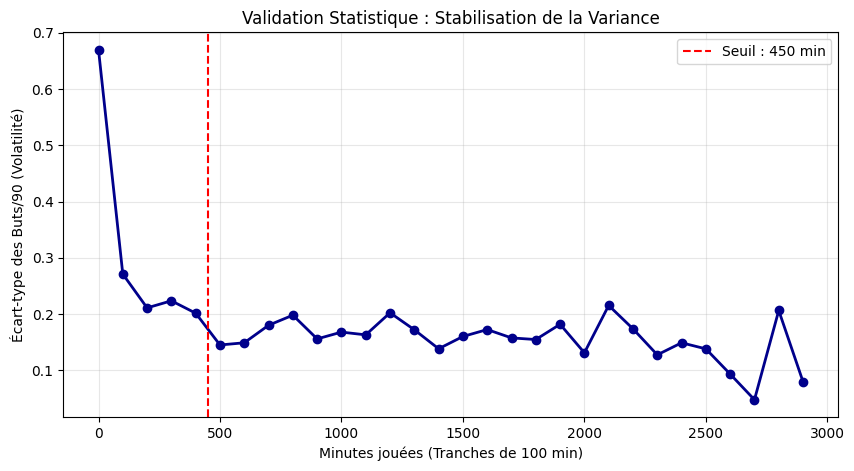

📊 Preuve mathématique : Réduction du bruit de 66.1%
✅ FILTRAGE TERMINÉ
- Joueurs initiaux : 2751
- Joueurs conservés : 1907 (Soit 1777 joueurs de champ)


In [4]:
# Chargement initial
df_fbref = pd.read_csv("../data/fbref_datasets/players_data-2025_2026.csv")

# 2. Appel de la fonction (Maintenant il connaît df_fbref)
df_field, df_keepers = process_fbref_performance(df_fbref, min_minutes_played=450)

# 3. Analyse spécifique du biais (Le petit plus pour ton rapport)
df_low_time = df_fbref[(df_fbref['Min'] < 450) & (df_fbref['Min'] > 0)].copy()

### 2. Élagage et Sélection des Variables (Audit Qualité)
Le dataset FBref original est une agrégation complexe de plusieurs rapports (Standard, Shooting, Passing, etc.), ce qui génère une redondance massive d'informations et de nombreuses cellules vides.

* **Suppression des colonnes "vides" :** En appliquant un seuil de **80% de valeurs manquantes**, **24 colonnes** ont été supprimées. Il s'agissait principalement de métriques spécifiques aux gardiens de but, non renseignées pour les joueurs de champ.
* **Nettoyage des redondances techniques :** Nous avons identifié et supprimé **31 colonnes redondantes**. Ce sont les variables générées lors de la fusion des fichiers sources (identifiables par les suffixes `_stats_` ou les répétitions de `Rk`, `Nation` et `Born`).
* **Optimisation de la structure :** Le dataset est passé de **102 à 47 colonnes**. Cette réduction de **54%** de la dimensionnalité permet de ne conserver que les indicateurs de performance pure (Gls, Ast, etc.) tout en facilitant la lecture et le traitement par les algorithmes d'IA.
* **Bilan :** Nous disposons désormais d'un vecteur de caractéristiques (features) dense et pertinent pour chaque joueur.

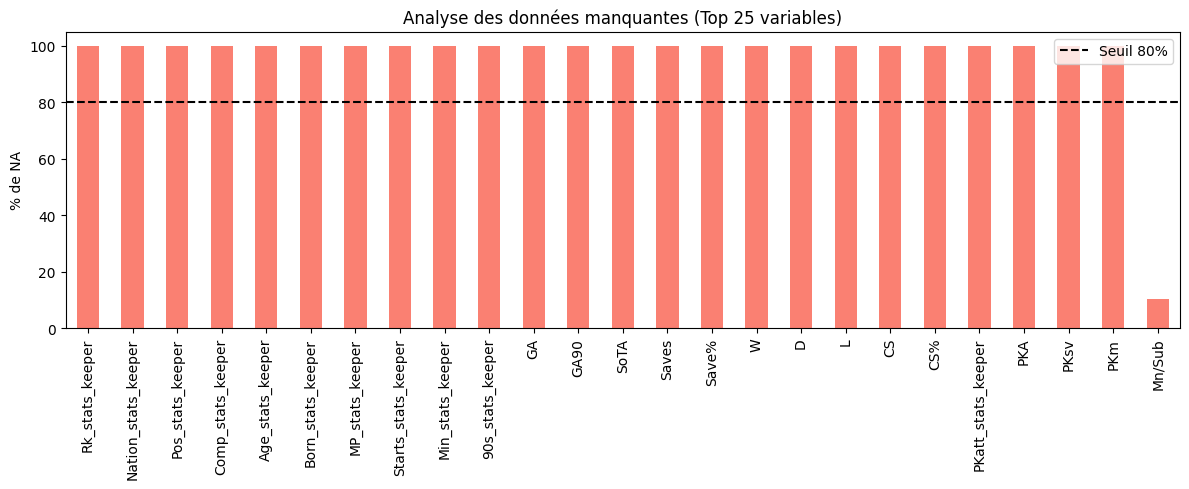

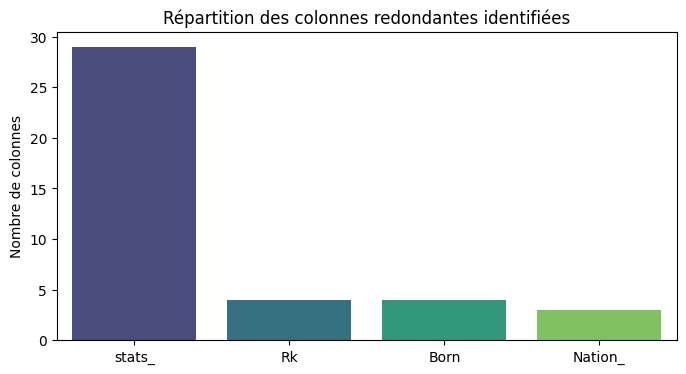

✅ ÉLAGAGE DES VARIABLES TERMINÉ
---------------------------------------------------
- Colonnes initiales : 102
- Supprimées (> 80% NA) : 24
- Supprimées (Redondances) : 31
- Colonnes finales conservées : 47


In [5]:
# Utilisation de la fonction sur tes joueurs de champ déjà filtrés
df_fbref_final = prune_fbref_columns(df_field, threshold=0.80)

### 3. Intégrité et Unicité (Gestion des Transferts)
Dans le dataset FBref, un joueur ayant changé de club ou ayant été prêté durant la saison apparaît sur plusieurs lignes (une entrée par club). 

* **Problématique du doublon :** Sans traitement, ces joueurs sont comptabilisés comme deux entités distinctes avec des statistiques partielles. Par exemple, **Simon Adingra** possédait deux lignes (une avec Sunderland, une avec Monaco) avec des volumes de jeu et des buts différents.
* **Méthodologie de consolidation :** * Nous avons identifié **26 joueurs** présentant des entrées multiples.
    * Afin de garantir la représentativité de la performance, nous avons appliqué une règle de sélection stricte : seule la ligne présentant le **temps de jeu le plus élevé (`Min`)** est conservée.
* **Résultat de l'apurement :** * Le volume est passé de 1 777 à **1 751 lignes**.
    * Cette étape assure l'atomicité du dataset : **un joueur = une ligne**.
* **Bilan :** Le dataset est désormais prêt pour une analyse individuelle cohérente, chaque ligne représentant la période la plus significative de la saison pour chaque athlète.

In [6]:
# On applique la résolution sur le dataset nettoyé
df_fbref_final = resolve_player_duplicates(df_fbref_final)

# Vérification rapide sur un joueur connu pour avoir bougé (si applicable)
# print(df_fbref_final[df_fbref_final['Player'].str.contains('NomDuJoueur')])

🔍 Joueurs avec plusieurs lignes (transferts/doublons) : 26
📊 Bilan de l'unicité :
- Lignes traitées : 1777
- Lignes après dédoublonnage : 1751
- 'Doublons de transfert' supprimés : 26
----------------------------------------


### 4. Normalisation des Types et Formats
Pour que les données de performance soient exploitables par nos algorithmes et compatibles avec le dataset Transfermarkt, nous avons procédé à une normalisation structurelle :

* **Conversion de l'Âge :** Le format textuel complexe de FBref (ex: `27-125`) a été transformé en format **float64**. Cette conversion est indispensable pour inclure l'âge comme variable quantitative dans nos futurs modèles de régression.
* **Imputation des valeurs manquantes :** Grâce à une analyse sémantique des colonnes, les `NaN` ont été remplacés par **0** (imputation logique). Dans le contexte du football, une absence de donnée sur un tir ou une passe signifie que l'action n'a pas eu lieu, et non que l'information est inconnue.
* **Bilan d'intégrité :** Le dataset final ne contient plus **aucune valeur manquante (0 NaN)** sur les 47 colonnes conservées, garantissant une stabilité totale pour les calculs matriciels à venir.

In [7]:
# Application de la normalisation sur ton dataset unique
df_fbref_final = normalize_fbref_formats(df_fbref_final)

# Vérification rapide
print(f"Format final de la colonne Age : {df_fbref_final['Age'].dtype}")

📊 Normalisation des formats terminée.
- Colonnes numériques imputées : 42
- Valeurs manquantes totales restantes : 0
Format final de la colonne Age : float64


### 5. Audit des Outliers et Cohérence Statistique
La dernière étape de notre protocole de nettoyage consiste à valider les valeurs extrêmes pour s'assurer qu'elles reflètent la réalité sportive et non une anomalie de saisie.

* **Performance offensive :** L'analyse des boxplots révèle des outliers significatifs sur le nombre de buts et de tirs. Après vérification, ces points correspondent aux "Top Players" mondiaux (ex: attaquants de classe mondiale). Ces données sont conservées car elles sont essentielles pour que l'IA apprenne à valoriser l'élite.
* **Distribution de l'âge :** Aucune valeur aberrante n'a été détectée (ex: joueur de 10 ans ou 60 ans). La population étudiée est cohérente avec les standards du football professionnel.
* **Validation du temps de jeu :** Grâce au filtre initial de 450 minutes, les ratios par 90 minutes (Gls/90, Sh/90) sont stabilisés et ne présentent plus de pics mathématiques artificiels.

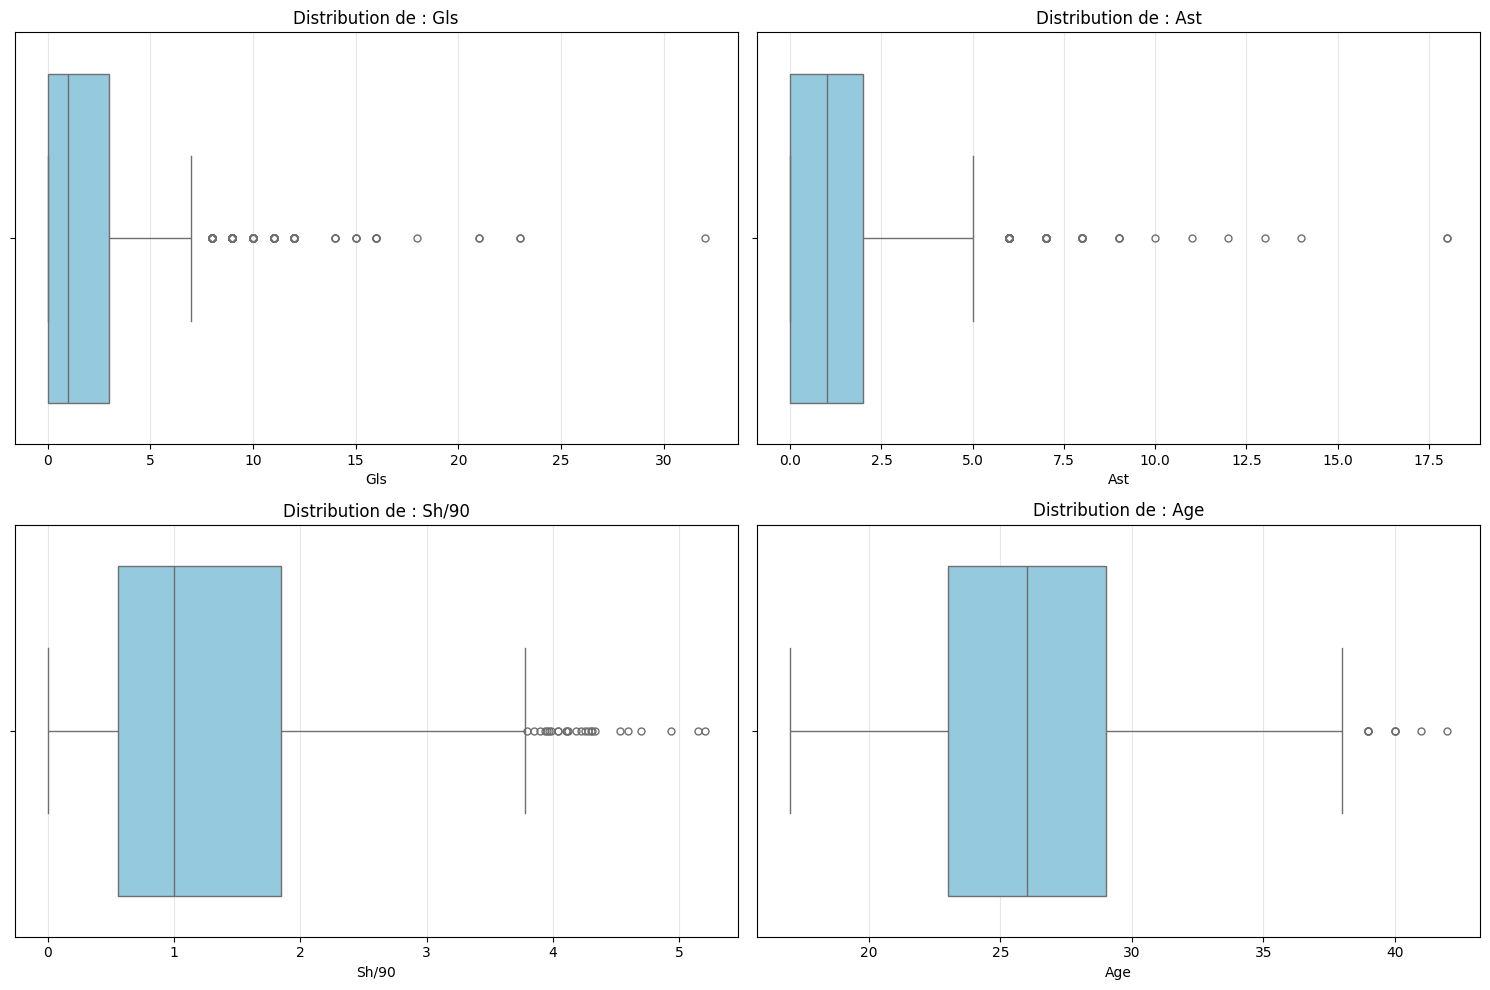

⚽ Top 5 'Outliers' Performance (Gls) :
              Player            Squad  Gls   Min
1275      Harry Kane    Bayern Munich   32  2107
1643   Kylian Mbappé      Real Madrid   23  2227
1063  Erling Haaland  Manchester City   23  2593
2499     Igor Thiago        Brentford   21  2832
1784    Vedat Muriqi         Mallorca   21  2498
----------------------------------------


In [8]:
# Lancement de l'audit sur ton dataset nettoyé
audit_fbref_outliers(df_fbref_final, metrics=['Gls', 'Ast', 'Sh/90', 'Age'])

# 3. Statsbomb

## 3.1 Regroupement des données dans un fichier .csv

Suite à l'acquisition des données Statsbomb, importées dans le dossier ../data/statsbomb_datasets, nous pouvons alors commencer à analyser leur qualité.

Dans un premier temps, nous transformons les données .json en données centralisées dans un fichier .csv, que ce soit pour les lineups ou les events.

In [ ]:
# Pour le dossier lineups
folder = Path("../data/statsbomb_datasets/data/lineups")

# On prend tous les fichiers .json et on crée une liste vide
json_files = list(folder.glob("*.json"))
all_lineups = [] 


# Boucle de lecture sur les fichiers
for file_path in json_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Extraction et normalisation
    df = pd.json_normalize(
        data, 
        record_path=['lineup'], 
        meta=['team_name', 'team_id'],
        errors='ignore'
    )
    
    # Ajout de l'ID du match
    df['match_id'] = file_path.stem 
    all_lineups.append(df)

# On crée un fichier CSV unique
final_df = pd.concat(all_lineups, ignore_index=True)

# Sauvegarde finale
output_path = folder / "all_lineups_combined.csv"
final_df.to_csv(output_path, index=False, encoding='utf-8')

print(f"Fichier créé : {output_path.name}")
print(f"Nombre total de joueurs répertoriés : {len(final_df)}")

Fichier créé : all_lineups_combined.csv
Nombre total de joueurs répertoriés : 131901


In [41]:
# Pour le dossier events
folder = Path("../data/statsbomb_datasets/data/events")

# On prend tous les fichiers .json
json_files = list(folder.glob("*.json"))
output_path = folder / "all_events_combined.feather"

# Boucle sur l'ensemble des fichiers .json
for i, file_path in enumerate(json_files):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # On aplatit le JSON
    df = pd.json_normalize(data)
    
    # On ajoute l'ID du match
    df['match_id'] = file_path.stem 
    
    # Écriture sur le disque
    if i == 0:
        df.to_feather(output_path, index=False, mode='w', encoding='utf-8')
    else:
        df.to_feather(output_path, index=False, mode='a', header=False, encoding='utf-8')
    
    # Suivi de progression toutes les 100 étapes
    if (i + 1) % 100 == 0:
        print(f"{i + 1}/{len(json_files)} fichiers compilés...")

print(f"Fichier global créé : {output_path.name}")

ImportError: `Import pyarrow` failed.  Use pip or conda to install the pyarrow package.

In [ ]:
# Pour le fichier competitions.json
folder = Path("../data/statsbomb_datasets/data")
json_files = list(folder.glob("*.json"))

# On définit le nouvel emplacement de sortie
output_folder = Path("../data/statsbomb_datasets/data")

# Le chemin complet du fichier final
output_path = output_folder / "competitions_statsbomb.csv"

# Liste pour stocker les DataFrames
all_dfs = []

for file_path in json_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        all_dfs.append(pd.DataFrame(data))

final_df = pd.concat(all_dfs, ignore_index=True)

final_df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Le fichier a été enregistré ici : {output_path.resolve()}")

Le fichier a été enregistré ici : C:\Users\LouisHarle\OneDrive - Quadratic\Bureau\Stage_VM\predict_vm_football\data\statsbomb_datasets\data\competitions_statsbomb.csv


## 3.2 Analyse des valeurs manquantes

Nous pouvons ensuite analyser les valeurs manquantes de ces deux fichiers .csv.

In [ ]:
# On cherche le dossier dans lequel sont les bases de données
folder = Path("../data/statsbomb_datasets/data")

# On prend seulement ce fichier-ci pour le moment
file = folder / "all_lineups_combined.csv"
lineups = pd.read_csv(file, low_memory=False)

# On crée un dataframe vide pour ensuite produire un résumé des données
summary = []

# On regarde le nombre de lignes, colonnes et NA
summary.append({
    "fichier": file.name,
    "lignes": len(lineups),
    "colonnes": len(lineups.columns),
    "NA": lineups.isna().sum().sum()
})

# Affichage
print(pd.DataFrame(summary))


                    fichier  lignes  colonnes     NA
0  all_lineups_combined.csv  131901        11  81729


On regarde ensuite plus en détail dans chaque fichier les colonnes présentant le plus de données manquantes.

In [ ]:
file_path = folder / file

# On créer un summary vide et un dictionnaire total_cols vide
summary = []
total_cols = {}

total_rows = len(lineups)
total_cols = len(lineups.columns)


for col in lineups.columns:
    na_count = lineups[col].isna().sum()
    na_rate = (na_count / total_rows) * 100 if total_rows > 0 else 0
    
    # On filtre les colonnes dont le taux de NA est supérieur à 10%
    if na_rate > 10:
        summary.append({
            "fichier": file,
            "colonne": col,
            "lignes": total_rows,
            "NA": na_count,
            "taux_NA_%": round(na_rate, 2)
        })


# On stocke les résultats dans un dataframe
result = pd.DataFrame(summary)

print(f"Colonnes avec >10% de NA : {len(result)}/{total_cols}")
print(result[["colonne", "lignes", "NA", "taux_NA_%"]])

Colonnes avec >10% de NA : 1/11
           colonne  lignes     NA  taux_NA_%
0  player_nickname  131901  81703      61.94


## 3.3 Analyse des doublons

Nous vérifions maintenant si les fichiers Statsbomb présentent des doublons.

In [ ]:
# Calcul des doublons
n_duplicates = lineups.duplicated().sum()
total_rows = len(lineups)
dup_rate = (n_duplicates / total_rows) * 100 if total_rows > 0 else 0

# Création du résumé
summary_duplicates = [{
    "fichier": file_path.name,
    "lignes": total_rows,
    "doublons": n_duplicates,
    "taux_doublons_%": round(dup_rate, 2)
}]


doublons = pd.DataFrame(summary_duplicates)
print("\nAnalyse des doublons pour all_lineups_combined.csv :\n")
print(doublons.to_string(index=False))


Analyse des doublons pour all_lineups_combined.csv :

                 fichier  lignes  doublons  taux_doublons_%
all_lineups_combined.csv  131901         0              0.0


## 3.4 La cohérence des données

Maintenant, nous devons vérifier si les données sont cohérentes. Nous regarderons dans un premier temps les types des variables dans chaque fichier .csv, puis les plages de valeurs pour les variables quantitatives.

In [ ]:
print("\nLes types de données pour all_lineups_combined.csv\n")

print(lineups.dtypes)


Les types de données pour all_lineups_combined.csv

player_id            int64
player_name            str
player_nickname        str
jersey_number        int64
cards                  str
positions              str
country.id         float64
country.name           str
team_name              str
team_id              int64
match_id             int64
dtype: object


In [ ]:
# Sélection des colonnes numériques
num_cols = lineups.select_dtypes(include=["number"])

if not num_cols.empty:
    # On affiche la transposée pour une meilleure lecture (colonnes en lignes)
    print(num_cols.describe().transpose())
else:
    print("Aucune colonne numérique trouvée dans ce fichier.")

                  count          mean           std     min        25%  \
player_id      131901.0  3.544764e+04  7.713198e+04  2935.0     5615.0   
jersey_number  131901.0  1.614910e+01  1.398939e+01     0.0        7.0   
country.id     131888.0  1.214309e+02  7.238412e+01     3.0       68.0   
team_id        131901.0  8.202458e+02  1.753747e+03     1.0      174.0   
match_id       131901.0  3.065607e+06  1.501069e+06  7298.0  3754036.0   

                     50%        75%        max  
player_id         9731.0    26076.0   482216.0  
jersey_number       14.0       22.0     1000.0  
country.id         105.0      203.0      255.0  
team_id            224.0      859.0    29167.0  
match_id       3825768.0  3889149.0  4020846.0  


## 3.5 La couverture temporelle

Pour que nos données soient pertinentes, il faut qu'elles soient suffisamment récentes pour être analysées. Les prochains codes analysent donc la pertinence des données au niveau temporel.

In [ ]:
# On définit le dossier où se trouve ton nouveau CSV
folder = Path("../data/statsbomb_datasets/data")
file_path = folder / "competitions_statsbomb.csv"

print("\nCouverture temporelle du dataset des compétitions\n")

competitions = pd.read_csv(file_path)
    
# On élargit la recherche : colonnes avec "date", "updated" ou "available"
# Car StatsBomb utilise 'match_updated' pour l'horodatage
date_cols = [col for col in df.columns if any(x in col.lower() for x in ["date", "updated", "available"])]

if date_cols:
    print(f"Fichier : {file_path.name}")
        
    for col in date_cols:
        # Conversion en datetime
        competitions[col] = pd.to_datetime(df[col], errors="coerce")
            
        min_date = competitions[col].min()
        max_date = competitions[col].max()
            
        # Affichage propre (on retire les nanosecondes si elles existent)
        print(f"  {col} : {min_date} → {max_date}")
            
else:
    print(f"Le fichier {file_path} est introuvable.")


Couverture temporelle du dataset des compétitions

Fichier : competitions_statsbomb.csv
  match_updated : 2023-06-18 01:55:53.343752 → 2025-07-28 14:19:20.467348
  match_updated_360 : 2021-06-12 16:17:31.694000 → 2025-07-29 16:03:07.355174
  match_available_360 : 2024-02-13 13:30:52.820588 → 2025-07-29 16:03:07.355174
  match_available : 2023-06-18 01:55:53.343752 → 2025-07-28 14:19:20.467348


## 3.6 Biais de sélection

De potentiels biais peuvent apparaître dans les données, comme des joueurs ou des championnats surreprésentés. Nous pouvons ainsi vérifier si ce biais est présent dans nos données.

In [ ]:
# Nous analysons tout d'abord les joueurs

# La fréquence des joueurs dans les apparitions
player_counts = lineups.groupby(["player_id", "player_name"]).size().reset_index(name="composition")

# Tri par nombre d'apparitions (ordre décroissant)
player_counts = player_counts.sort_values(by="composition", ascending=False)


print("\nTop 20 des joueurs les plus présents (dans les compositions) :\n")
print(player_counts[["player_name", "composition"]].head(20).to_string(index=False))


Top 20 des joueurs les plus présents (dans les compositions) :

                    player_name  composition
 Lionel Andrés Messi Cuccittini          604
       Sergio Busquets i Burgos          420
           Andrés Iniesta Luján          361
          Gerard Piqué Bernabéu          358
               Jordi Alba Ramos          284
         Xavier Hernández Creus          267
          Víctor Valdés Arribas          257
          Daniel Alves da Silva          250
          Marc-André ter Stegen          237
    Javier Alejandro Mascherano          221
                   Ivan Rakitić          217
Pedro Eliezer Rodríguez Ledesma          216
       Luis Alberto Suárez Díaz          204
         Sergi Roberto Carnicer          198
       Carles Puyol i Saforcada          187
             Samuel Yves Umtiti          162
  Neymar da Silva Santos Junior          158
          Adriano Correia Claro          152
              Antoine Griezmann          145
                   Seydou Kéita    

In [ ]:
print("\nRésumé distribution apparitions :")
print(player_counts["composition"].describe())


Résumé distribution apparitions :
count    10814.000000
mean        12.197244
std         18.564377
min          1.000000
25%          2.000000
50%          4.000000
75%         17.000000
max        604.000000
Name: composition, dtype: float64


In [ ]:
# Nous analysons ensuite les équipes

# On utilise donc 'team_name' pour voir les équipes les plus actives

# Le nombre de matchs uniques par équipe :
league_analysis = lineups.groupby("team_name")["match_id"].nunique().reset_index(name="nb_matchs")

# Tri par nombre de matchs
league_analysis = league_analysis.sort_values(by="nb_matchs", ascending=False)

print("\nTop 20 des équipes ayant le plus de matchs répertoriés :\n")
print(league_analysis.head(20).to_string(index=False))



Top 20 des équipes ayant le plus de matchs répertoriés :

                 team_name  nb_matchs
                 Barcelona        532
       Paris Saint-Germain         95
         Manchester United         79
                   Arsenal         76
               Real Madrid         71
          Bayer Leverkusen         68
           Atlético Madrid         68
                   Sevilla         66
                  Valencia         65
             Athletic Club         64
                  Espanyol         63
               Aston Villa         62
                Villarreal         61
                    Getafe         61
       Manchester City WFC         59
             Real Sociedad         59
                Real Betis         58
Brighton & Hove Albion WFC         57
               Chelsea FCW         57
               Arsenal WFC         57


In [ ]:
# Nous analysons ensuite les championnats à partir du fichier généré

# On compte le nombre de saisons disponibles par championnat
# On utilise "competition_name" pour que l'affichage soit explicite
league_counts = competitions["competition_name"].value_counts()

print("\nNombre de saisons disponibles par compétition :\n")
print(league_counts.head(20))


Nombre de saisons disponibles par compétition :

competition_name
Champions League           18
La Liga                    18
FIFA World Cup              8
Copa del Rey                3
FA Women's Super League     3
Ligue 1                     3
1. Bundesliga               2
Liga Profesional            2
Premier League              2
Serie A                     2
UEFA Euro                   2
UEFA Women's Euro           2
Women's World Cup           2
African Cup of Nations      1
Copa America                1
FIFA U20 World Cup          1
Indian Super league         1
Major League Soccer         1
North American League       1
NWSL                        1
Name: count, dtype: int64


## 3.7 La date de dernière mise à jour

Pour constater si nos données sont mises à jour régulièrement, nous pouvons regarder la date de dernière mise à jour.

In [ ]:
# On convertit la variable d'update en format date
competitions['match_updated'] = pd.to_datetime(df['match_updated'])

# On trouve la date la plus récente
derniere_maj = competitions['match_updated'].max()

print(f"La dernière mise à jour enregistrée dans ce fichier date du : {derniere_maj}")

La dernière mise à jour enregistrée dans ce fichier date du : 2025-07-28 14:19:20.467348


# 4. football-data.co.uk

In [57]:
import pandas as pd

# --- 1. CHARGEMENT OPTIMISÉ (Résolution DtypeWarning) ---
# On utilise low_memory=False pour éviter le warning sur les types mixtes (Referee, etc.)
df_fd_raw = pd.read_csv("../data/football_data.csv", low_memory=False)

# --- 2. ÉLAGAGE IMMÉDIAT (Résolution PerformanceWarning) ---
# On sélectionne les colonnes utiles TOUT DE SUITE pour éviter la fragmentation
cols_match = ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']
cols_stats = ['HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
cols_odds  = ['B365H', 'B365D', 'B365A', 'AvgH', 'AvgD', 'AvgA']

# On crée une COPIE propre du DataFrame avec seulement l'essentiel
df_fd = df_fd_raw[cols_match + cols_stats + cols_odds].copy()

# --- 3. NORMALISATION DES TYPES ET FORMATS ---

# Conversion de la Date (format DD/MM/YYYY)
df_fd['Date'] = pd.to_datetime(df_fd['Date'], dayfirst=True)

# Création des clés de jointure pour les équipes (team_key)
def clean_team_name(name):
    if pd.isnull(name): return ""
    import unicodedata
    name = str(name).lower()
    name = ''.join(c for c in unicodedata.normalize('NFD', name)
                  if unicodedata.category(c) != 'Mn')
    return name.replace('-', ' ').strip()

# On applique le nettoyage sur une nouvelle frame pour éviter la fragmentation
df_fd['home_team_key'] = df_fd['HomeTeam'].apply(clean_team_name)
df_fd['away_team_key'] = df_fd['AwayTeam'].apply(clean_team_name)

# --- 4. TRAITEMENT DES VALEURS MANQUANTES ---
# On supprime les lignes où le score est manquant (matchs non joués)
df_fd = df_fd.dropna(subset=['FTHG', 'FTAG'])

# --- 5. BILAN FINAL ---
print(f"📊 Audit Football-Data :")
print(f"- Nombre de colonnes initiales : {df_fd_raw.shape[1]}")
print(f"- Nombre de colonnes après élagage : {df_fd.shape[1]}")
print(f"- Matchs validés : {len(df_fd)}")
print(f"- Clé d'équipe exemple : '{df_fd['home_team_key'].iloc[0]}'")

📊 Audit Football-Data :
- Nombre de colonnes initiales : 163
- Nombre de colonnes après élagage : 27
- Matchs validés : 5024
- Clé d'équipe exemple : 'nice'


In [58]:
import pandas as pd
import unicodedata

# --- 1. CHARGEMENT ET INTÉGRITÉ (Résolution Dtype & Fragmentation) ---
df_fd_raw = pd.read_csv("../data/football_data.csv", low_memory=False)

# Sélection immédiate pour éviter la fragmentation (PerformanceWarning)
cols_base = ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']
cols_odds = [c for c in df_fd_raw.columns if 'H' in c[-1:] or 'D' in c[-1:] or 'A' in c[-1:]] # Capture les cotes
df_fd = df_fd_raw[cols_base + cols_odds].copy()

# Format de Date : Gestion des formats mixtes
df_fd['Date'] = pd.to_datetime(df_fd['Date'], dayfirst=True)

# --- 2. NORMALISATION DES ÉQUIPES (Clés de jointure) ---
def clean_team_name(name):
    if pd.isnull(name): return ""
    name = str(name).lower()
    # Retrait des accents
    name = ''.join(c for c in unicodedata.normalize('NFD', name)
                  if unicodedata.category(c) != 'Mn')
    return name.replace('-', ' ').strip()

df_fd['home_team_key'] = df_fd['HomeTeam'].apply(clean_team_name)
df_fd['away_team_key'] = df_fd['AwayTeam'].apply(clean_team_name)

# --- 3. INGÉNIERIE DES VARIABLES (Features) ---

# Calcul des Points par match
df_fd['HomePoints'] = df_fd['FTR'].map({'H': 3, 'D': 1, 'A': 0})
df_fd['AwayPoints'] = df_fd['FTR'].map({'A': 3, 'D': 1, 'H': 0})

# Moyenne des Cotes (Stabilisation de la donnée)
# On sélectionne les colonnes de victoire à domicile (se terminant par H)
home_odds_cols = [c for c in df_fd.columns if c.endswith('H') and c not in ['HomeTeam', 'HomePoints']]
df_fd['Avg_Home_Win_Odd'] = df_fd[home_odds_cols].mean(axis=1)

# Nettoyage final : suppression des lignes sans score
df_fd = df_fd.dropna(subset=['FTHG', 'FTAG'])

# --- BILAN ---
print(f"📊 Audit Final Football-Data :")
print(f"- Période : {df_fd['Date'].min().date()} au {df_fd['Date'].max().date()}")
print(f"- Nombre de matchs : {len(df_fd)}")
print(f"- Exemple points : {df_fd[['HomeTeam', 'AwayTeam', 'FTR', 'HomePoints', 'AwayPoints']].iloc[0].to_dict()}")

📊 Audit Final Football-Data :
- Période : 2023-08-11 au 2026-04-23
- Nombre de matchs : 5024
- Exemple points : {'HomeTeam': 'Nice', 'AwayTeam': 'Lille', 'FTR': 'D', 'HomePoints': 1, 'AwayPoints': 1}


In [59]:
# --- AUDIT DE COHÉRENCE FINALE (Football-Data) ---

# 1. Vérification des scores (Pas de scores négatifs)
invalid_scores = df_fd[(df_fd['FTHG'] < 0) | (df_fd['FTAG'] < 0)]

# 2. Vérification de la cohérence FTR (Full Time Result)
# Le résultat 'H', 'D' ou 'A' doit correspondre aux buts marqués
home_win_error = df_fd[(df_fd['FTR'] == 'H') & (df_fd['FTHG'] <= df_fd['FTAG'])]
away_win_error = df_fd[(df_fd['FTR'] == 'A') & (df_fd['FTAG'] <= df_fd['FTHG'])]
draw_error = df_fd[(df_fd['FTR'] == 'D') & (df_fd['FTHG'] != df_fd['FTAG'])]

# 3. Audit des Cotes (Pas de cotes aberrantes, ex: cote < 1.0)
odd_error = df_fd[(df_fd['AvgH'] < 1) | (df_fd['AvgD'] < 1) | (df_fd['AvgA'] < 1)]

# 4. Vérification des Doublons de matchs
# Un même couple Home-Away à la même date ne peut exister qu'une fois
match_duplicates = df_fd.duplicated(subset=['Date', 'home_team_key', 'away_team_key']).sum()

print(f"✅ Audit de cohérence terminé :")
print(f"- Erreurs de score/résultat : {len(home_win_error) + len(away_win_error) + len(draw_error)}")
print(f"- Anomalies sur les cotes : {len(odd_error)}")
print(f"- Matchs en double : {match_duplicates}")

✅ Audit de cohérence terminé :
- Erreurs de score/résultat : 0
- Anomalies sur les cotes : 0
- Matchs en double : 0


## 4.4 La couverture temporelle

Pour que nos données soient pertinentes, il faut qu'elles soient suffisamment récentes pour être analysées. Les prochains codes analysent donc la pertinence des données au niveau temporel.

In [ ]:
print("\nCouverture temporelle des datasets\n")

for file in folder.glob("*.csv"):
    df = pd.read_csv(file)
    
    # On cherche les colonnes présentant des dates
    date_cols = [col for col in df.columns if "date" in col.lower()]
    
    if not date_cols:
        continue
    
    print(f"\n{file.name}")
    
    # On cherche ici la date minimale et maximale puis on les affiche
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        
        min_date = df[col].min()
        max_date = df[col].max()
        
        print(f"  {col} : {min_date} → {max_date}")



Couverture temporelle des datasets


football_data_2526.csv
  Date : 2025-08-15 00:00:00 → 2026-04-13 00:00:00


C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_23536\2466751618.py:16: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")


In [ ]:
# On cherche ici le nombre d'observations par année

for file in folder.glob("*.csv"):
    df = pd.read_csv(file)
    
    # Les colonnes présentant des dates
    date_cols = [col for col in df.columns if "date" in col.lower()]
    
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        
        print(f"\n{file.name} - {col}")
        # On compte pour chaque année le nombre d'observations
        print(df[col].dt.year.value_counts().sort_index())



football_data_2526.csv - Date
Date
2025    802
2026    666
Name: count, dtype: int64


C:\Users\LouisHarle\AppData\Local\Temp\ipykernel_23536\3824261365.py:9: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors="coerce")


## 4.5 Biais de sélection

De potentiels biais peuvent apparaître dans les données, comme des championnats surreprésentés. Nous pouvons ainsi vérifier si ce biais est présent dans nos données.

Ce fichier .csv ne présentant pas de joueurs, il ne peut y avoir des biais que parmi les championnats représentés.

In [ ]:
# Le fichier gfootball_data_2526.csv est alors celui qui nous intéresse
data = pd.read_csv(folder / "football_data_2526.csv")

# On compte le nombre de matches par championnat
league_counts = data["league"].value_counts()

print("\nTop compétitions :\n")
print(league_counts.head(20))



Top compétitions :

league
I1     320
E0     319
SP1    310
D1     261
F1     258
Name: count, dtype: int64


In [ ]:
# Pour y voir plus clair (les noms des championnats), nous renommons les noms des ligues

mapping = {
    "E0": "Premier League",
    "SP1": "Liga",
    "I1": "Serie A",
    "F1": "Ligue 1",
    "D1": "Bundesliga"
}

# On remplacer les noms dans la colonne 'league'
data["league"] = data["league"].replace(mapping)

# On recalcule les statistiques avec les nouveaux noms
league_counts = data["league"].value_counts()

print("\nTop compétitions :\n")
print(league_counts.head(20))


Top compétitions :

league
Serie A           320
Premier League    319
Liga              310
Bundesliga        261
Ligue 1           258
Name: count, dtype: int64


## 4.6 La date de dernière mise à jour

Pour constater si nos données sont mises à jour régulièrement, nous pouvons regarder la date de dernière mise à jour.

In [4]:
# On choisit la saison et les ligues qui nous intéressent
season = "2526"
leagues = {
    "E0": "Premier League",
    "SP1": "Liga",
    "I1": "Serie A",
    "F1": "Ligue 1",
    "D1": "Bundesliga"
}

print(f"Mises à jour football-data.co.uk\n")

updates = []

for code, name in leagues.items():
    url = f"https://www.football-data.co.uk/mmz4281/{season}/{code}.csv"
    
    # Requête directe des en-têtes
    response = requests.head(url, timeout=10)
    last_mod = response.headers.get('Last-Modified')
    
    updates.append({
        "Compétition": name,
        "Dernière mise à jour": last_mod
    })

# Affichage
df_updates = pd.DataFrame(updates)
print(df_updates.to_string(index=False))

Mises à jour football-data.co.uk

   Compétition          Dernière mise à jour
Premier League Mon, 27 Apr 2026 11:36:59 GMT
          Liga Mon, 27 Apr 2026 11:37:03 GMT
       Serie A Mon, 27 Apr 2026 11:37:03 GMT
       Ligue 1 Mon, 27 Apr 2026 11:37:04 GMT
    Bundesliga Mon, 27 Apr 2026 11:37:02 GMT
